In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

In [19]:
print("Libraries Imported Successfully.")
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

Libraries Imported Successfully.


# ============================================
# EXPERIMENT 1: CLUSTERING ON IRIS DATASET
# ============================================

In [20]:
print("\n" + "="*60)
print("EXPERIMENT 1: Clustering on Iris Dataset")
print("="*60)

# Load Iris dataset
iris_data = load_iris()
X_iris = iris_data.data
y_iris = iris_data.target

print(f"Feature shape: {X_iris.shape}")
print(f"Number of classes: {len(np.unique(y_iris))}")
print(f"Classes: {iris_data.target_names}")


EXPERIMENT 1: Clustering on Iris Dataset
Feature shape: (150, 4)
Number of classes: 3
Classes: ['setosa' 'versicolor' 'virginica']


In [21]:
# Standardize features
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

print("Data standardized successfully.")

Data standardized successfully.


In [22]:
# ==================================================
# 1. K-Means Clustering on Iris
# ==================================================
print("\n" + "-"*60)
print("Algorithm 1: K-Means Clustering (Iris)")
print("-"*60)

kmeans_iris = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_iris_pred = kmeans_iris.fit_predict(X_iris_scaled)

# Evaluation metrics
silhouette_iris_km = silhouette_score(X_iris_scaled, kmeans_iris_pred)
davies_bouldin_iris_km = davies_bouldin_score(X_iris_scaled, kmeans_iris_pred)
calinski_iris_km = calinski_harabasz_score(X_iris_scaled, kmeans_iris_pred)

print(f"Silhouette Score: {silhouette_iris_km:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_iris_km:.4f}")
print(f"Calinski-Harabasz Score: {calinski_iris_km:.4f}")
print(f"Inertia: {kmeans_iris.inertia_:.4f}")


------------------------------------------------------------
Algorithm 1: K-Means Clustering (Iris)
------------------------------------------------------------
Silhouette Score: 0.4599
Davies-Bouldin Index: 0.8336
Calinski-Harabasz Score: 241.9044
Inertia: 139.8205


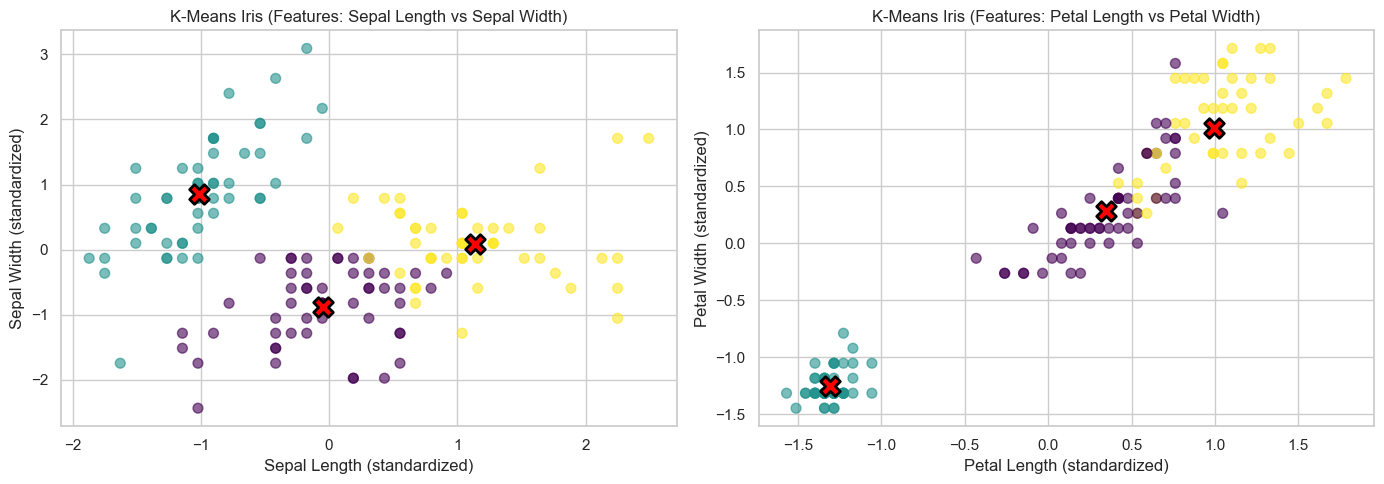

In [23]:
# Visualize K-Means on Iris (2D projection)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Using first two features
axes[0].scatter(X_iris_scaled[:, 0], X_iris_scaled[:, 1], 
                c=kmeans_iris_pred, cmap='viridis', s=50, alpha=0.6)
axes[0].scatter(kmeans_iris.cluster_centers_[:, 0], 
                kmeans_iris.cluster_centers_[:, 1], 
                c='red', marker='X', s=200, edgecolors='black', linewidths=2)
axes[0].set_title('K-Means Iris (Features: Sepal Length vs Sepal Width)')
axes[0].set_xlabel('Sepal Length (standardized)')
axes[0].set_ylabel('Sepal Width (standardized)')

# Using different two features
axes[1].scatter(X_iris_scaled[:, 2], X_iris_scaled[:, 3], 
                c=kmeans_iris_pred, cmap='viridis', s=50, alpha=0.6)
axes[1].scatter(kmeans_iris.cluster_centers_[:, 2], 
                kmeans_iris.cluster_centers_[:, 3], 
                c='red', marker='X', s=200, edgecolors='black', linewidths=2)
axes[1].set_title('K-Means Iris (Features: Petal Length vs Petal Width)')
axes[1].set_xlabel('Petal Length (standardized)')
axes[1].set_ylabel('Petal Width (standardized)')

plt.tight_layout()
plt.show()

In [24]:
# ==================================================
# 2. Agglomerative Clustering on Iris
# ==================================================
print("\n" + "-"*60)
print("Algorithm 2: Agglomerative Clustering (Iris)")
print("-"*60)

agg_iris = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_iris_pred = agg_iris.fit_predict(X_iris_scaled)

# Evaluation metrics
silhouette_iris_agg = silhouette_score(X_iris_scaled, agg_iris_pred)
davies_bouldin_iris_agg = davies_bouldin_score(X_iris_scaled, agg_iris_pred)
calinski_iris_agg = calinski_harabasz_score(X_iris_scaled, agg_iris_pred)

print(f"Silhouette Score: {silhouette_iris_agg:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_iris_agg:.4f}")
print(f"Calinski-Harabasz Score: {calinski_iris_agg:.4f}")


------------------------------------------------------------
Algorithm 2: Agglomerative Clustering (Iris)
------------------------------------------------------------
Silhouette Score: 0.4467
Davies-Bouldin Index: 0.8035
Calinski-Harabasz Score: 222.7192


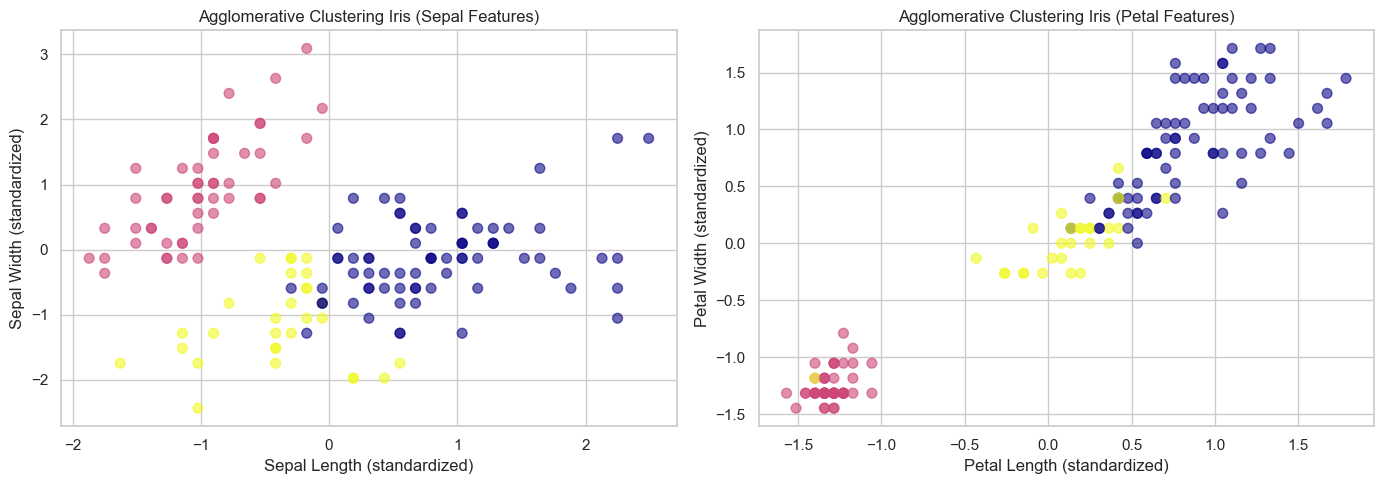

In [25]:
# Visualize Agglomerative Clustering on Iris
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_iris_scaled[:, 0], X_iris_scaled[:, 1], 
                c=agg_iris_pred, cmap='plasma', s=50, alpha=0.6)
axes[0].set_title('Agglomerative Clustering Iris (Sepal Features)')
axes[0].set_xlabel('Sepal Length (standardized)')
axes[0].set_ylabel('Sepal Width (standardized)')

axes[1].scatter(X_iris_scaled[:, 2], X_iris_scaled[:, 3], 
                c=agg_iris_pred, cmap='plasma', s=50, alpha=0.6)
axes[1].set_title('Agglomerative Clustering Iris (Petal Features)')
axes[1].set_xlabel('Petal Length (standardized)')
axes[1].set_ylabel('Petal Width (standardized)')

plt.tight_layout()
plt.show()

In [26]:
# ==================================================
# 3. DBSCAN on Iris
# ==================================================
print("\n" + "-"*60)
print("Algorithm 3: DBSCAN (Iris)")
print("-"*60)

dbscan_iris = DBSCAN(eps=0.5, min_samples=5)
dbscan_iris_pred = dbscan_iris.fit_predict(X_iris_scaled)

# Count clusters and noise points
n_clusters_dbscan = len(set(dbscan_iris_pred)) - (1 if -1 in dbscan_iris_pred else 0)
n_noise = list(dbscan_iris_pred).count(-1)

print(f"Number of clusters: {n_clusters_dbscan}")
print(f"Number of noise points: {n_noise}")

# Evaluation metrics (only if we have at least 2 clusters)
if n_clusters_dbscan > 1:
    silhouette_iris_dbscan = silhouette_score(X_iris_scaled, dbscan_iris_pred)
    davies_bouldin_iris_dbscan = davies_bouldin_score(X_iris_scaled, dbscan_iris_pred)
    calinski_iris_dbscan = calinski_harabasz_score(X_iris_scaled, dbscan_iris_pred)
    
    print(f"Silhouette Score: {silhouette_iris_dbscan:.4f}")
    print(f"Davies-Bouldin Index: {davies_bouldin_iris_dbscan:.4f}")
    print(f"Calinski-Harabasz Score: {calinski_iris_dbscan:.4f}")
else:
    print("Not enough clusters for evaluation metrics.")


------------------------------------------------------------
Algorithm 3: DBSCAN (Iris)
------------------------------------------------------------
Number of clusters: 2
Number of noise points: 34
Silhouette Score: 0.3565
Davies-Bouldin Index: 7.1241
Calinski-Harabasz Score: 84.5103


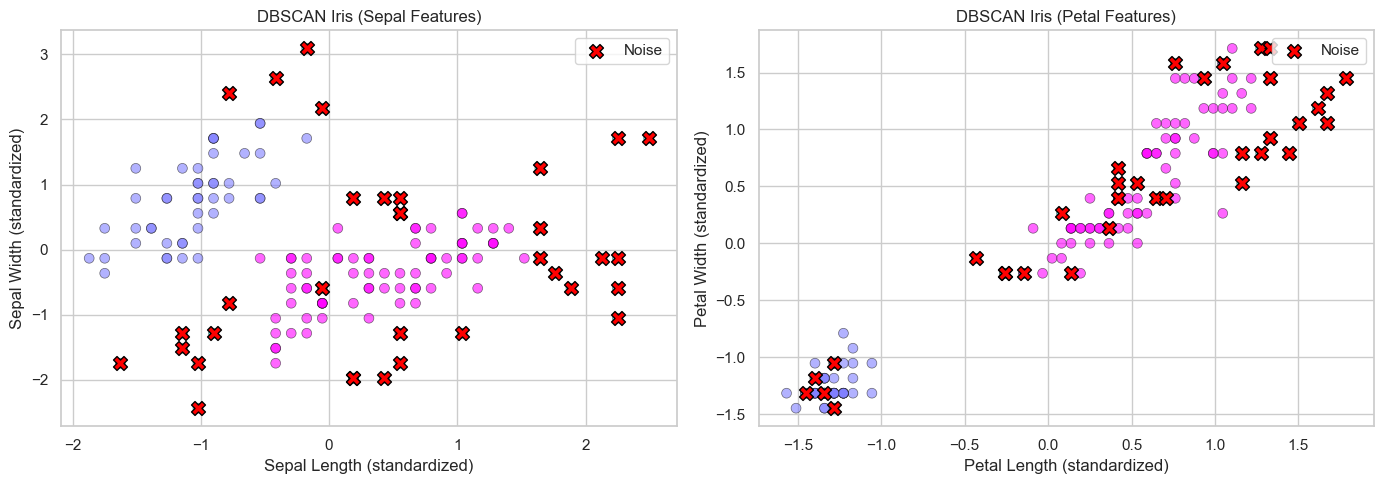

In [27]:
# Visualize DBSCAN on Iris
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mark noise points differently
colors = dbscan_iris_pred.copy()
colors[colors == -1] = -1

axes[0].scatter(X_iris_scaled[:, 0], X_iris_scaled[:, 1], 
                c=dbscan_iris_pred, cmap='cool', s=50, alpha=0.6, 
                edgecolors='k', linewidth=0.5)
axes[0].scatter(X_iris_scaled[dbscan_iris_pred == -1, 0], 
                X_iris_scaled[dbscan_iris_pred == -1, 1], 
                c='red', marker='X', s=100, edgecolors='black', linewidths=1, label='Noise')
axes[0].set_title('DBSCAN Iris (Sepal Features)')
axes[0].set_xlabel('Sepal Length (standardized)')
axes[0].set_ylabel('Sepal Width (standardized)')
axes[0].legend()

axes[1].scatter(X_iris_scaled[:, 2], X_iris_scaled[:, 3], 
                c=dbscan_iris_pred, cmap='cool', s=50, alpha=0.6,
                edgecolors='k', linewidth=0.5)
axes[1].scatter(X_iris_scaled[dbscan_iris_pred == -1, 2], 
                X_iris_scaled[dbscan_iris_pred == -1, 3], 
                c='red', marker='X', s=100, edgecolors='black', linewidths=1, label='Noise')
axes[1].set_title('DBSCAN Iris (Petal Features)')
axes[1].set_xlabel('Petal Length (standardized)')
axes[1].set_ylabel('Petal Width (standardized)')
axes[1].legend()

plt.tight_layout()
plt.show()

# ============================================
# EXPERIMENT 2: CLUSTERING ON BREAST CANCER DATASET
# ============================================

In [28]:
print("\n" + "="*60)
print("EXPERIMENT 2: Clustering on Breast Cancer Dataset")
print("="*60)

# Load Breast Cancer dataset
bc_data = load_breast_cancer()
X_bc = bc_data.data
y_bc = bc_data.target

print(f"Feature shape: {X_bc.shape}")
print(f"Number of classes: {len(np.unique(y_bc))}")
print(f"Classes: {bc_data.target_names}")


EXPERIMENT 2: Clustering on Breast Cancer Dataset
Feature shape: (569, 30)
Number of classes: 2
Classes: ['malignant' 'benign']


In [29]:
# Standardize features
scaler_bc = StandardScaler()
X_bc_scaled = scaler_bc.fit_transform(X_bc)

print("Data standardized successfully.")

Data standardized successfully.


In [30]:
# ==================================================
# 1. K-Means Clustering on Breast Cancer
# ==================================================
print("\n" + "-"*60)
print("Algorithm 1: K-Means Clustering (Breast Cancer)")
print("-"*60)

kmeans_bc = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_bc_pred = kmeans_bc.fit_predict(X_bc_scaled)

# Evaluation metrics
silhouette_bc_km = silhouette_score(X_bc_scaled, kmeans_bc_pred)
davies_bouldin_bc_km = davies_bouldin_score(X_bc_scaled, kmeans_bc_pred)
calinski_bc_km = calinski_harabasz_score(X_bc_scaled, kmeans_bc_pred)

print(f"Silhouette Score: {silhouette_bc_km:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_bc_km:.4f}")
print(f"Calinski-Harabasz Score: {calinski_bc_km:.4f}")
print(f"Inertia: {kmeans_bc.inertia_:.4f}")


------------------------------------------------------------
Algorithm 1: K-Means Clustering (Breast Cancer)
------------------------------------------------------------
Silhouette Score: 0.3434
Davies-Bouldin Index: 1.3205
Calinski-Harabasz Score: 267.6917
Inertia: 11595.5266


In [31]:
# ==================================================
# 2. Agglomerative Clustering on Breast Cancer
# ==================================================
print("\n" + "-"*60)
print("Algorithm 2: Agglomerative Clustering (Breast Cancer)")
print("-"*60)

agg_bc = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg_bc_pred = agg_bc.fit_predict(X_bc_scaled)

# Evaluation metrics
silhouette_bc_agg = silhouette_score(X_bc_scaled, agg_bc_pred)
davies_bouldin_bc_agg = davies_bouldin_score(X_bc_scaled, agg_bc_pred)
calinski_bc_agg = calinski_harabasz_score(X_bc_scaled, agg_bc_pred)

print(f"Silhouette Score: {silhouette_bc_agg:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_bc_agg:.4f}")
print(f"Calinski-Harabasz Score: {calinski_bc_agg:.4f}")


------------------------------------------------------------
Algorithm 2: Agglomerative Clustering (Breast Cancer)
------------------------------------------------------------
Silhouette Score: 0.3394
Davies-Bouldin Index: 1.3700
Calinski-Harabasz Score: 248.6288


In [32]:
# ==================================================
# 3. DBSCAN on Breast Cancer
# ==================================================
print("\n" + "-"*60)
print("Algorithm 3: DBSCAN (Breast Cancer)")
print("-"*60)

dbscan_bc = DBSCAN(eps=3.0, min_samples=5)
dbscan_bc_pred = dbscan_bc.fit_predict(X_bc_scaled)

# Count clusters and noise points
n_clusters_dbscan_bc = len(set(dbscan_bc_pred)) - (1 if -1 in dbscan_bc_pred else 0)
n_noise_bc = list(dbscan_bc_pred).count(-1)

print(f"Number of clusters: {n_clusters_dbscan_bc}")
print(f"Number of noise points: {n_noise_bc}")

# Evaluation metrics (only if we have at least 2 clusters)
if n_clusters_dbscan_bc > 1:
    silhouette_bc_dbscan = silhouette_score(X_bc_scaled, dbscan_bc_pred)
    davies_bouldin_bc_dbscan = davies_bouldin_score(X_bc_scaled, dbscan_bc_pred)
    calinski_bc_dbscan = calinski_harabasz_score(X_bc_scaled, dbscan_bc_pred)
    
    print(f"Silhouette Score: {silhouette_bc_dbscan:.4f}")
    print(f"Davies-Bouldin Index: {davies_bouldin_bc_dbscan:.4f}")
    print(f"Calinski-Harabasz Score: {calinski_bc_dbscan:.4f}")
else:
    print("Not enough clusters for evaluation metrics.")


------------------------------------------------------------
Algorithm 3: DBSCAN (Breast Cancer)
------------------------------------------------------------
Number of clusters: 1
Number of noise points: 121
Not enough clusters for evaluation metrics.


# ============================================
# EXPERIMENT 3: CLUSTERING ON TV MARKETING DATASET
# ============================================

In [33]:
print("\n" + "="*60)
print("EXPERIMENT 3: Clustering on TV Marketing Dataset")
print("="*60)

try:
    df_tv = pd.read_csv('TvMarketing.csv')
    print("Data Loaded Successfully.")
    print(f"\nShape of Data: {df_tv.shape}")
    print(f"\nFirst 5 rows:\n{df_tv.head()}")
    print(f"\nData Info:")
    print(df_tv.info())
except FileNotFoundError:
    print("Error: 'TvMarketing.csv' not found. Please ensure the dataset is in the current directory.")


EXPERIMENT 3: Clustering on TV Marketing Dataset
Data Loaded Successfully.

Shape of Data: (200, 2)

First 5 rows:
      TV  Sales
0  230.1   22.1
1   44.5   10.4
2   17.2    9.3
3  151.5   18.5
4  180.8   12.9

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB
None


In [34]:
# Extract features for clustering
if 'df_tv' in locals():
    # Use all columns except if there are non-numeric columns
    X_tv = df_tv.select_dtypes(include=[np.number]).values
    
    # Standardize features
    scaler_tv = StandardScaler()
    X_tv_scaled = scaler_tv.fit_transform(X_tv)
    
    print(f"Features shape: {X_tv.shape}")
    print(f"Columns used: {list(df_tv.select_dtypes(include=[np.number]).columns)}")
    print("Data standardized successfully.")

Features shape: (200, 2)
Columns used: ['TV', 'Sales']
Data standardized successfully.


In [35]:
if 'X_tv_scaled' in locals():
    # ==================================================
    # 1. K-Means Clustering on TV Marketing
    # ==================================================
    print("\n" + "-"*60)
    print("Algorithm 1: K-Means Clustering (TV Marketing)")
    print("-"*60)
    
    kmeans_tv = KMeans(n_clusters=3, random_state=42, n_init=10)
    kmeans_tv_pred = kmeans_tv.fit_predict(X_tv_scaled)
    
    # Evaluation metrics
    silhouette_tv_km = silhouette_score(X_tv_scaled, kmeans_tv_pred)
    davies_bouldin_tv_km = davies_bouldin_score(X_tv_scaled, kmeans_tv_pred)
    calinski_tv_km = calinski_harabasz_score(X_tv_scaled, kmeans_tv_pred)
    
    print(f"Silhouette Score: {silhouette_tv_km:.4f}")
    print(f"Davies-Bouldin Index: {davies_bouldin_tv_km:.4f}")
    print(f"Calinski-Harabasz Score: {calinski_tv_km:.4f}")
    print(f"Inertia: {kmeans_tv.inertia_:.4f}")


------------------------------------------------------------
Algorithm 1: K-Means Clustering (TV Marketing)
------------------------------------------------------------
Silhouette Score: 0.4565
Davies-Bouldin Index: 0.7669
Calinski-Harabasz Score: 352.0416
Inertia: 87.4503


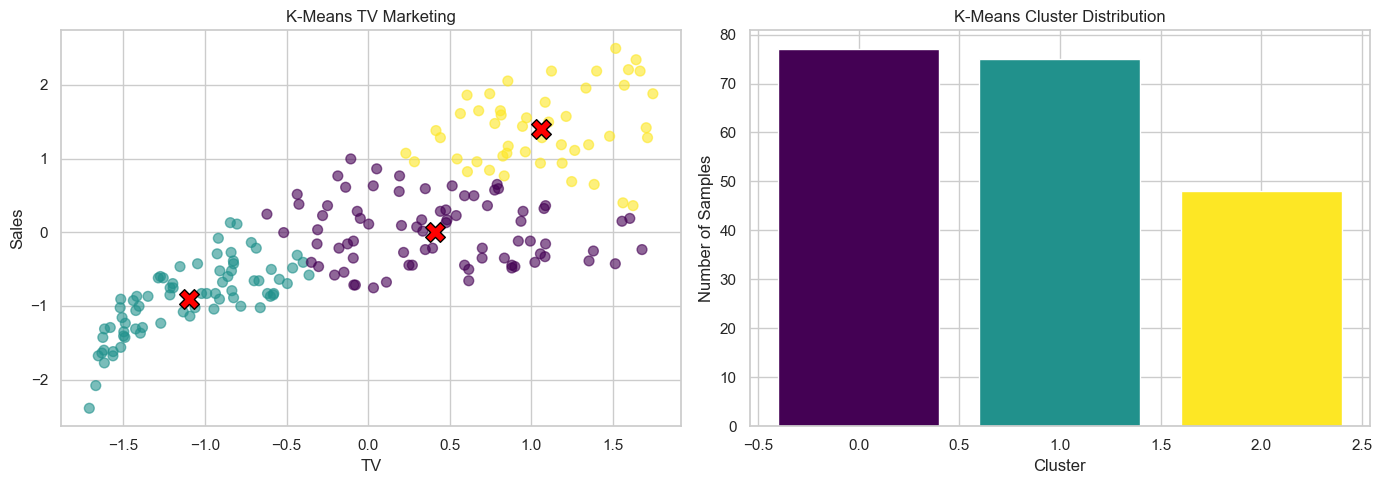

In [36]:
if 'X_tv_scaled' in locals():
    # Visualize K-Means on TV Marketing
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    if X_tv_scaled.shape[1] == 2:
        # 2D visualization for 2 features
        axes[0].scatter(X_tv_scaled[:, 0], X_tv_scaled[:, 1],
                    c=kmeans_tv_pred, cmap='viridis', s=50, alpha=0.6)
        axes[0].scatter(kmeans_tv.cluster_centers_[:, 0], kmeans_tv.cluster_centers_[:, 1],
                    c='red', marker='X', s=200, edgecolors='black')
        axes[0].set_xlabel(df_tv.select_dtypes(include=[np.number]).columns[0])
        axes[0].set_ylabel(df_tv.select_dtypes(include=[np.number]).columns[1])
        axes[0].set_title('K-Means TV Marketing')
        
        # Cluster distribution
        unique, counts = np.unique(kmeans_tv_pred, return_counts=True)
        axes[1].bar(unique, counts, color=plt.cm.viridis(unique / max(unique)))
        axes[1].set_xlabel('Cluster')
        axes[1].set_ylabel('Number of Samples')
        axes[1].set_title('K-Means Cluster Distribution')
    else:
        axes[0].text(0.5, 0.5, 'Cannot visualize with more than 2 features in 2D', 
                    ha='center', va='center', transform=axes[0].transAxes)
        
        # Cluster distribution
        unique, counts = np.unique(kmeans_tv_pred, return_counts=True)
        axes[1].bar(unique, counts, color=plt.cm.viridis(unique / max(unique)))
        axes[1].set_xlabel('Cluster')
        axes[1].set_ylabel('Number of Samples')
        axes[1].set_title('K-Means Cluster Distribution')
    
    plt.tight_layout()
    plt.show()

In [37]:
if 'X_tv_scaled' in locals():
    # ==================================================
    # 2. Agglomerative Clustering on TV Marketing
    # ==================================================
    print("\n" + "-"*60)
    print("Algorithm 2: Agglomerative Clustering (TV Marketing)")
    print("-"*60)
    
    agg_tv = AgglomerativeClustering(n_clusters=3, linkage='ward')
    agg_tv_pred = agg_tv.fit_predict(X_tv_scaled)
    
    # Evaluation metrics
    silhouette_tv_agg = silhouette_score(X_tv_scaled, agg_tv_pred)
    davies_bouldin_tv_agg = davies_bouldin_score(X_tv_scaled, agg_tv_pred)
    calinski_tv_agg = calinski_harabasz_score(X_tv_scaled, agg_tv_pred)
    
    print(f"Silhouette Score: {silhouette_tv_agg:.4f}")
    print(f"Davies-Bouldin Index: {davies_bouldin_tv_agg:.4f}")
    print(f"Calinski-Harabasz Score: {calinski_tv_agg:.4f}")


------------------------------------------------------------
Algorithm 2: Agglomerative Clustering (TV Marketing)
------------------------------------------------------------
Silhouette Score: 0.4614
Davies-Bouldin Index: 0.7557
Calinski-Harabasz Score: 343.0274


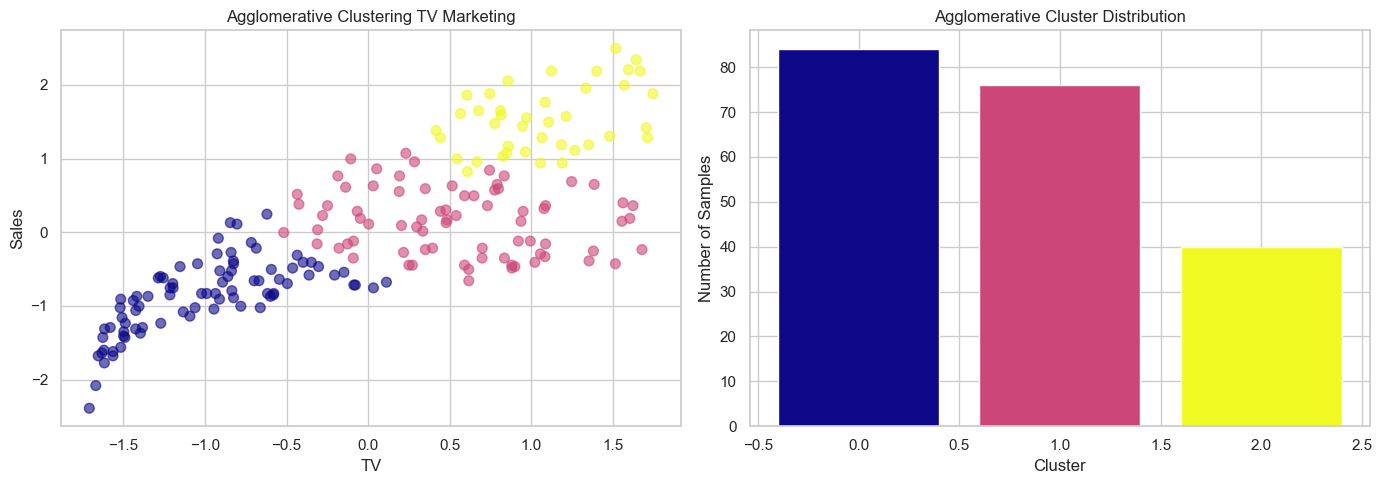

In [38]:
if 'X_tv_scaled' in locals():
    # Visualize Agglomerative Clustering on TV Marketing
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    if X_tv_scaled.shape[1] == 2:
        # 2D visualization for 2 features
        axes[0].scatter(X_tv_scaled[:, 0], X_tv_scaled[:, 1],
                    c=agg_tv_pred, cmap='plasma', s=50, alpha=0.6)
        axes[0].set_xlabel(df_tv.select_dtypes(include=[np.number]).columns[0])
        axes[0].set_ylabel(df_tv.select_dtypes(include=[np.number]).columns[1])
        axes[0].set_title('Agglomerative Clustering TV Marketing')
        
        # Cluster distribution
        unique, counts = np.unique(agg_tv_pred, return_counts=True)
        axes[1].bar(unique, counts, color=plt.cm.plasma(unique / max(unique)))
        axes[1].set_xlabel('Cluster')
        axes[1].set_ylabel('Number of Samples')
        axes[1].set_title('Agglomerative Cluster Distribution')
    else:
        axes[0].text(0.5, 0.5, 'Cannot visualize with more than 2 features in 2D', 
                    ha='center', va='center', transform=axes[0].transAxes)
        
        # Cluster distribution
        unique, counts = np.unique(agg_tv_pred, return_counts=True)
        axes[1].bar(unique, counts, color=plt.cm.plasma(unique / max(unique)))
        axes[1].set_xlabel('Cluster')
        axes[1].set_ylabel('Number of Samples')
        axes[1].set_title('Agglomerative Cluster Distribution')
    
    plt.tight_layout()
    plt.show()

In [39]:
if 'X_tv_scaled' in locals():
    # ==================================================
    # 3. DBSCAN on TV Marketing
    # ==================================================
    print("\n" + "-"*60)
    print("Algorithm 3: DBSCAN (TV Marketing)")
    print("-"*60)
    
    dbscan_tv = DBSCAN(eps=0.5, min_samples=5)
    dbscan_tv_pred = dbscan_tv.fit_predict(X_tv_scaled)
    
    # Count clusters and noise points
    n_clusters_dbscan_tv = len(set(dbscan_tv_pred)) - (1 if -1 in dbscan_tv_pred else 0)
    n_noise_tv = list(dbscan_tv_pred).count(-1)
    
    print(f"Number of clusters: {n_clusters_dbscan_tv}")
    print(f"Number of noise points: {n_noise_tv}")
    
    # Evaluation metrics (only if we have at least 2 clusters)
    if n_clusters_dbscan_tv > 1:
        silhouette_tv_dbscan = silhouette_score(X_tv_scaled, dbscan_tv_pred)
        davies_bouldin_tv_dbscan = davies_bouldin_score(X_tv_scaled, dbscan_tv_pred)
        calinski_tv_dbscan = calinski_harabasz_score(X_tv_scaled, dbscan_tv_pred)
        
        print(f"Silhouette Score: {silhouette_tv_dbscan:.4f}")
        print(f"Davies-Bouldin Index: {davies_bouldin_tv_dbscan:.4f}")
        print(f"Calinski-Harabasz Score: {calinski_tv_dbscan:.4f}")
    else:
        print("Not enough clusters for evaluation metrics.")


------------------------------------------------------------
Algorithm 3: DBSCAN (TV Marketing)
------------------------------------------------------------
Number of clusters: 1
Number of noise points: 0
Not enough clusters for evaluation metrics.


C:\Users\vpahu\AppData\Local\Temp\ipykernel_24860\2674140503.py:20: RuntimeWarning: invalid value encountered in scalar divide
  colors = ['gray' if c == -1 else plt.cm.cool(c / max(unique[unique != -1])) for c in unique]


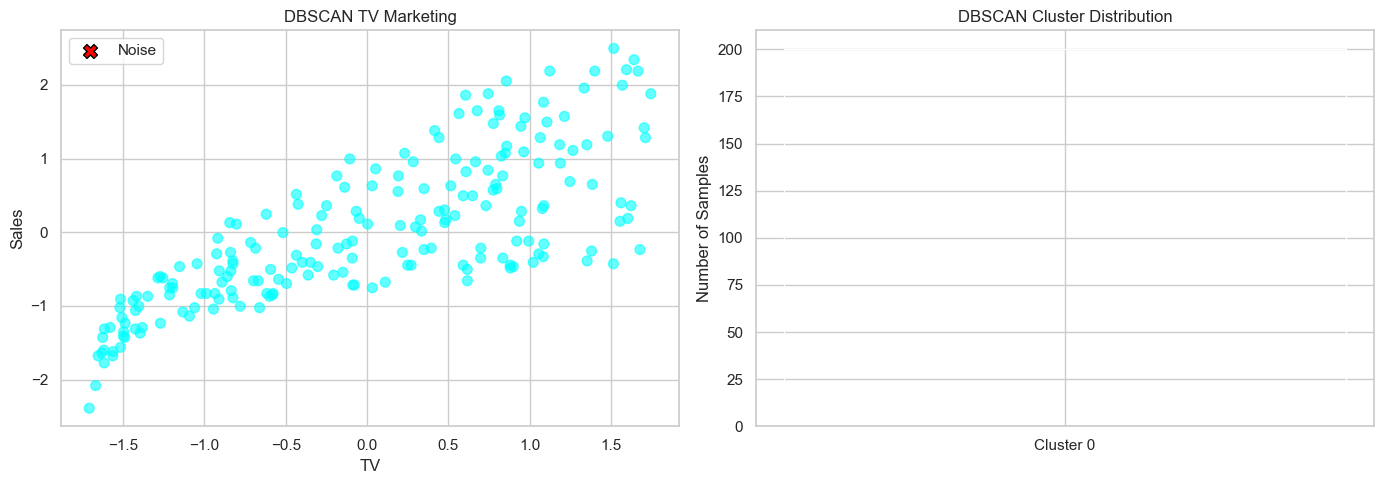

In [40]:
if 'X_tv_scaled' in locals():
    # Visualize DBSCAN on TV Marketing
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    if X_tv_scaled.shape[1] == 2:
        # 2D visualization for 2 features
        axes[0].scatter(X_tv_scaled[:, 0], X_tv_scaled[:, 1],
                    c=dbscan_tv_pred, cmap='cool', s=50, alpha=0.6)
        axes[0].scatter(X_tv_scaled[dbscan_tv_pred == -1, 0],
                    X_tv_scaled[dbscan_tv_pred == -1, 1],
                    c='red', marker='X', s=100, edgecolors='black', linewidths=1, label='Noise')
        axes[0].set_xlabel(df_tv.select_dtypes(include=[np.number]).columns[0])
        axes[0].set_ylabel(df_tv.select_dtypes(include=[np.number]).columns[1])
        axes[0].set_title('DBSCAN TV Marketing')
        axes[0].legend()
        
        # Cluster distribution
        unique, counts = np.unique(dbscan_tv_pred, return_counts=True)
        cluster_labels = [f'Cluster {c}' if c != -1 else 'Noise' for c in unique]
        colors = ['gray' if c == -1 else plt.cm.cool(c / max(unique[unique != -1])) for c in unique]
        axes[1].bar(range(len(unique)), counts, color=colors)
        axes[1].set_xticks(range(len(unique)))
        axes[1].set_xticklabels(cluster_labels)
        axes[1].set_ylabel('Number of Samples')
        axes[1].set_title('DBSCAN Cluster Distribution')
    else:
        axes[0].text(0.5, 0.5, 'Cannot visualize with more than 2 features in 2D', 
                    ha='center', va='center', transform=axes[0].transAxes)
        
        # Cluster distribution
        unique, counts = np.unique(dbscan_tv_pred, return_counts=True)
        cluster_labels = [f'Cluster {c}' if c != -1 else 'Noise' for c in unique]
        colors = ['gray' if c == -1 else plt.cm.cool(c / max(unique[unique != -1])) for c in unique]
        axes[1].bar(range(len(unique)), counts, color=colors)
        axes[1].set_xticks(range(len(unique)))
        axes[1].set_xticklabels(cluster_labels)
        axes[1].set_ylabel('Number of Samples')
        axes[1].set_title('DBSCAN Cluster Distribution')
    
    plt.tight_layout()
    plt.show()

# ============================================
# SUMMARY OF RESULTS
# ============================================

In [41]:
print("\n" + "="*60)
print("SUMMARY OF CLUSTERING RESULTS")
print("="*60)

# Create summary table
summary_data = {
    'Dataset': ['Iris', 'Iris', 'Iris', 'Breast Cancer', 'Breast Cancer', 'Breast Cancer'],
    'Algorithm': ['K-Means', 'Agglomerative', 'DBSCAN', 'K-Means', 'Agglomerative', 'DBSCAN'],
    'Silhouette Score': [silhouette_iris_km, silhouette_iris_agg, 'N/A', silhouette_bc_km, silhouette_bc_agg, 'N/A'],
    'Davies-Bouldin Index': [davies_bouldin_iris_km, davies_bouldin_iris_agg, 'N/A', davies_bouldin_bc_km, davies_bouldin_bc_agg, 'N/A']
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

print("\nNote: Lower Davies-Bouldin Index is better. Higher Silhouette Score is better.")
print("\nClustering Algorithms Overview:")
print("- K-Means: Partitioning method, requires specifying number of clusters")
print("- Agglomerative: Hierarchical clustering using linkage criterion")
print("- DBSCAN: Density-based clustering, automatically detects outliers")


SUMMARY OF CLUSTERING RESULTS

      Dataset     Algorithm Silhouette Score Davies-Bouldin Index
         Iris       K-Means         0.459948             0.833595
         Iris Agglomerative         0.446689             0.803467
         Iris        DBSCAN              N/A                  N/A
Breast Cancer       K-Means         0.343382              1.32051
Breast Cancer Agglomerative         0.339385             1.369964
Breast Cancer        DBSCAN              N/A                  N/A

Note: Lower Davies-Bouldin Index is better. Higher Silhouette Score is better.

Clustering Algorithms Overview:
- K-Means: Partitioning method, requires specifying number of clusters
- Agglomerative: Hierarchical clustering using linkage criterion
- DBSCAN: Density-based clustering, automatically detects outliers
